# OCEAN WAVES

In this notebook, we will observe the behaviour of ocean waves as they approach the eastern coast of Australia. Here is located the biggest coral reef system on Earth, the Great Barrier Reef, which attenuates waves as they cross the system.

Four example passes were selected with high SWH offshore, either due to a local storm or caused by swells coming from far away. By relying on the radar altimeter instrument alone, we cannot recognize in which of the two situations we are. Therefore, the corresponding ERA5 hourly model in the region was downloaded (from https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels?tab=overview), equipped with additional values which separate the wave components: shww (significant height of wind waves) and the shts (significant height of total swell).

In [32]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np

In [33]:
# Let's have a look at the structure of the altimetric data. Run the following cell, using the correct file path (do the same with the ERA5 model data):

ds = xr.open_dataset("data/eg1/ESACCI-SEASTATE-L2P-SWH-Sentinel-6_A-20210908T002954-fv01.nc") 

ds

<xarray.Dataset> Size: 897kB
Dimensions:                                        (time: 3374)
Coordinates:
  * time                                           (time) datetime64[ns] 27kB ...
    lon                                            (time) float64 27kB ...
    lat                                            (time) float64 27kB ...
    z                                              (time) float32 13kB ...
Data variables: (12/53)
    swh                                            (time) float64 27kB ...
    swh_rms                                        (time) float64 27kB ...
    swh_numval                                     (time) int8 3kB ...
    swh_with_8m_offset_correction                  (time) float64 27kB ...
    swh_with_8m_offset_correction_rms              (time) float64 27kB ...
    swh_with_8m_offset_correction_numval           (time) int8 3kB ...
    ...                                             ...
    swh_denoised                                   (time) float64 27kB ...
    swh_emd_uncertainty                            (time) float64 27kB ...
    swh_emd_noise                                  (time) float64 27kB ...
    swh_emd_imf1                                   (time) float64 27kB ...
    swh_uncertainty                                (time) float64 27kB ...
    ww3_peak_wave_period                           (time) float32 13kB ...
Attributes: (12/74)
    title:                           ESA CCI Sea State L2P from Poseidon-4 on...
    id:                              ESACCI-SEASTATE-L2P-SWH-SENTINEL-6 A-v5
    summary:                         This dataset contains along-track signif...
    platform:                        Sentinel-6 A
    instrument:                      Poseidon-4
    band:                            Ku
    ...                              ...
    time_coverage_end:               2021-09-08T01:26:07Z
    swh_rms_lut:                     /home/datawork-cersat-public/cache/proje...
    swh_intercalibration_lut:        /home/datawork-cersat-public/cache/proje...
    swh_absolute_calibration_lut:    /home/datawork-cersat-public/cache/proje...
    input_1hz:                       /home/datawork-cersat-public/cache/proje...
    input_file:                      S6A_P4_1B_LR______20210908T002954_202109...

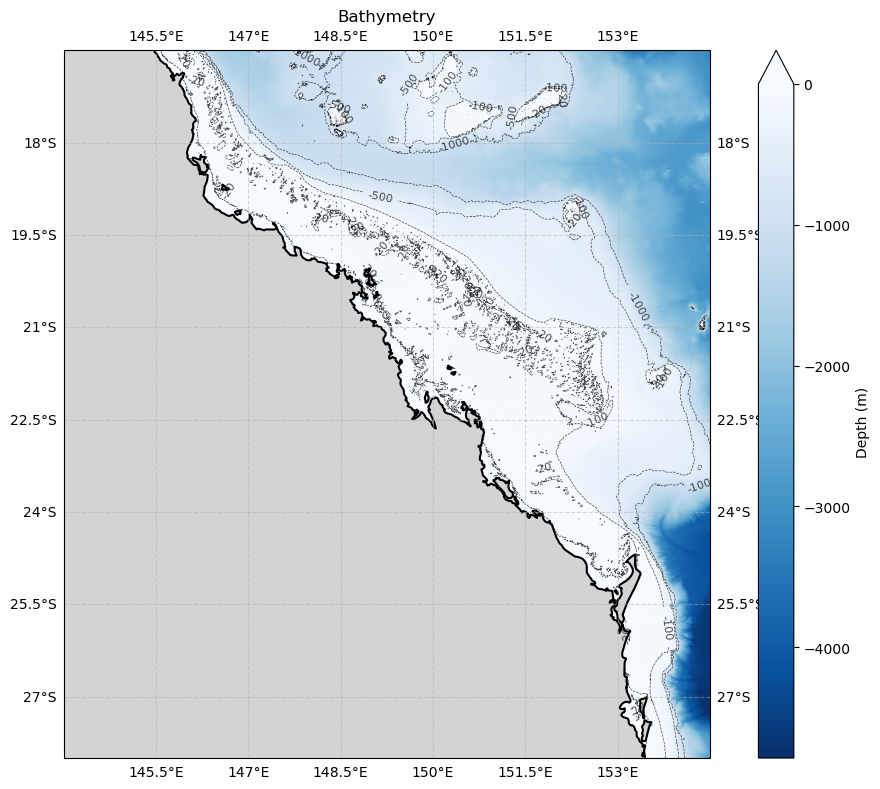

In [34]:
# Let's have a look at the region of interest, the Great Barrier Reef, by plotting the coastline and the bathymetry to identify the reef structure offshore. 
# Use the file provided gebco_2026_n-16.5_s-28.0_w144.0_e154.5.nc, downloaded from https://www.gebco.net/data-products/gridded-bathymetry-data.

ds_bathy = xr.open_dataset("data/gebco_2026_n-16.5_s-28.0_w144.0_e154.5.nc")

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': ccrs.PlateCarree()})

ds_bathy.elevation.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='Blues_r', vmax= 0, cbar_kwargs={'label': 'Depth (m)'})
line_levels = [-1000, -500, -100, -20]
contours = ds_bathy.elevation.plot.contour(ax=ax, transform=ccrs.PlateCarree(), levels= line_levels, colors = 'black', linewidths=0.5, alpha=0.7, add_colorbar= False)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=1)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.title("Bathymetry")
plt.tight_layout()
plt.show()


In [35]:
# For every example found there is a folder named "egx" with two netCDF files, one relative to Sentinel 6a (ESA Sea State CCI, L2 version 5) and one 
# with the data downloaded from the ERA5 model.
# Choose which example to look at and assign the correct file paths:

ds_s6 = xr.open_dataset("data/eg1/ESACCI-SEASTATE-L2P-SWH-Sentinel-6_A-20210908T002954-fv01.nc")
ds_era5 = xr.open_dataset("data/eg1/20210908T00.nc")

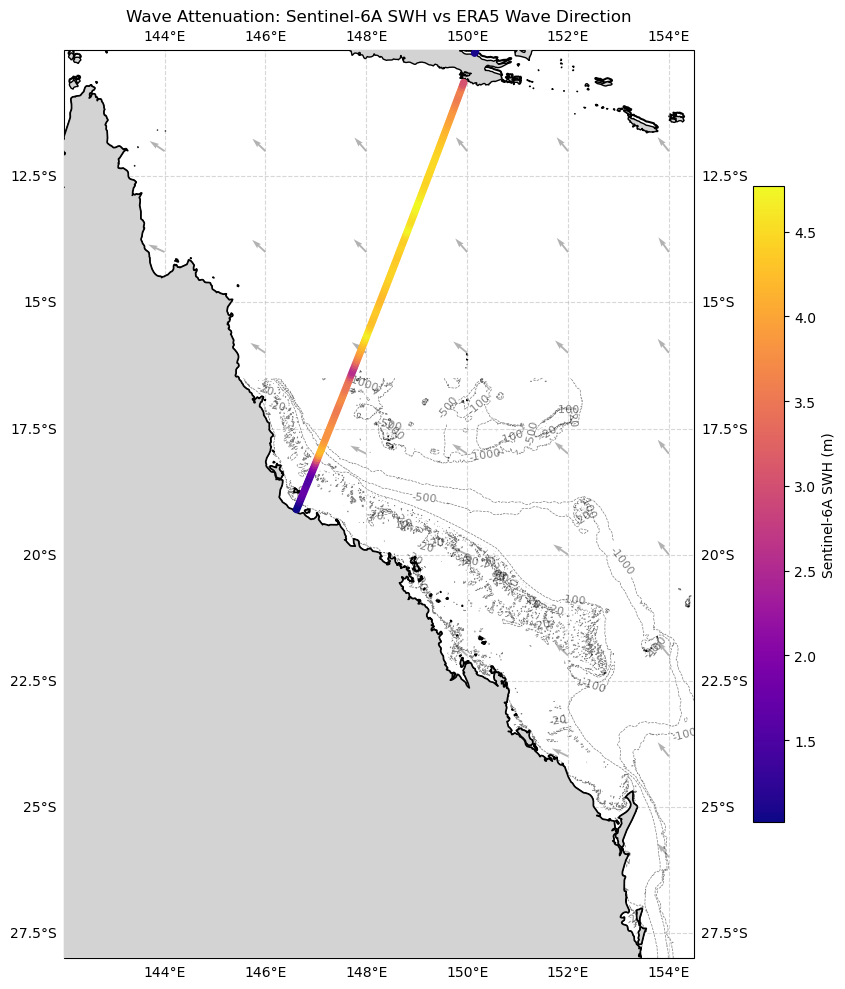

In [36]:
# On the geographical region considered we can extract the swh form the Sentinel 6a data record and plot its scatter plot to observe how it changes when 
# crossing the coral reef barrier. On this plot we can overlay the mean wave direction taken from the ERA 5 model.

# Set up the map projection and extent
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([142.0, 154.5, -28.0, -10.0], crs=ccrs.PlateCarree()) 

# Plot Bathymetry Contours (as done above)
line_levels = [-1000, -500, -100, -20]
contours = ds_bathy.elevation.plot.contour(
    ax=ax, transform=ccrs.PlateCarree(), levels=line_levels, 
    colors='black', linewidths=0.5, alpha=0.5, add_colorbar=False
)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

# Plot ERA5 Wave Direction (Arrows)
# We select the first time step
era5_step = ds_era5.isel(valid_time=0) 

# In ERA5, Mean Wave Direction (mwd) indicates the direction the waves are COMING FROM.
# 0 degrees = North, 90 degrees = East.
# We sub-sample [::4, ::4] so we only draw an arrow every 4th pixel
mwd_rad = np.radians(era5_step.mwd[::4, ::4])
u = -np.sin(mwd_rad)
v = -np.cos(mwd_rad)

# Draw the arrows
ax.quiver(
    era5_step.longitude[::4], era5_step.latitude[::4], 
    u, v, 
    transform=ccrs.PlateCarree(), 
    color='gray', alpha=0.6, scale=35, width=0.003
)

# Plot Sentinel-6A SWH Track (scatter of the swh parameter, "swh_denoised" is the variable name in the ESA_Sea_State data record)
# Filter for good quality open-ocean data using swh_quality_level flag
lat_min, lat_max = -28.0, -10.0
lon_min, lon_max = 142.0, 154.5
valid_s6 = ds_s6.where(
    (ds_s6.swh_quality_level == 3) &
    (ds_s6.lat >= lat_min) & (ds_s6.lat <= lat_max) &
    (ds_s6.lon >= lon_min) & (ds_s6.lon <= lon_max),
    drop=True
)

sc = ax.scatter(
    valid_s6.lon, valid_s6.lat, 
    c=valid_s6.swh_denoised,
    s=20, cmap='plasma', transform=ccrs.PlateCarree(),
    zorder=5 
)
plt.colorbar(sc, ax=ax, label='Sentinel-6A SWH (m)', shrink=0.7, pad=0.05)

#Add geographic features
ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.title("Wave Attenuation: Sentinel-6A SWH vs ERA5 Wave Direction")
plt.tight_layout()
plt.show()

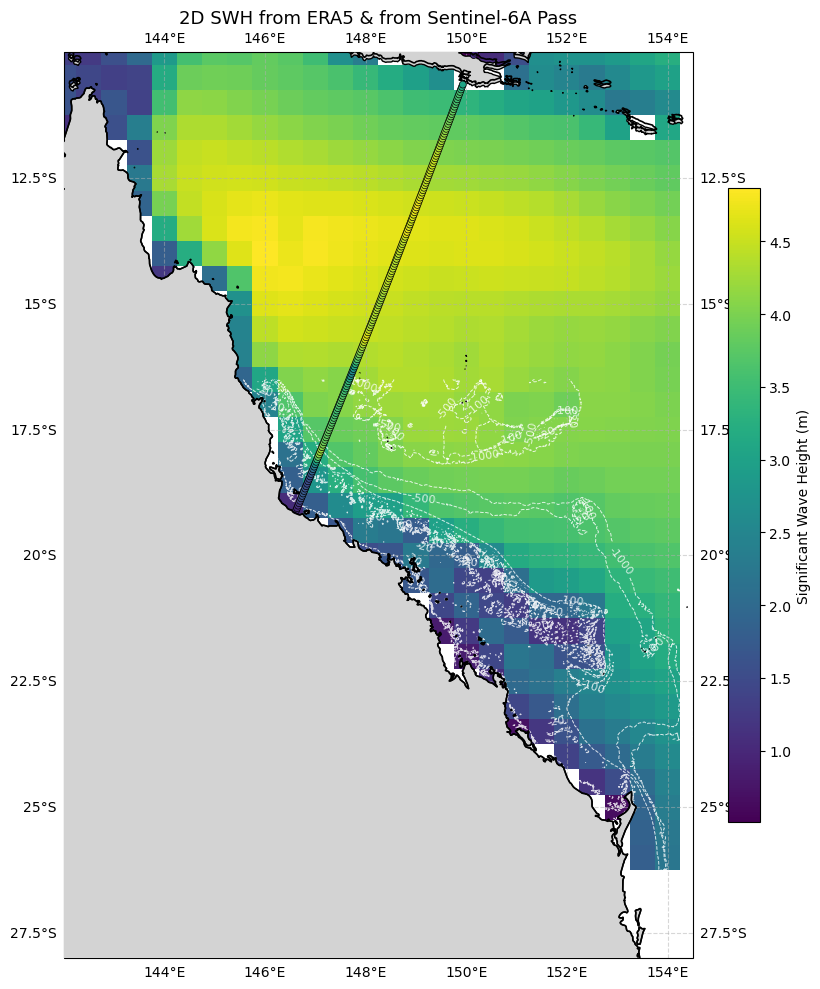

In [37]:
# We can now plot the 2D wave filed on the region as computed from the ERA 5 model, overlaid to the swh_denoised from the satellite track to see how they 
# compare also in terms of spatial resolution.

# Find the absolute min and max across BOTH datasets to set the colorbar limits
era5_min = float(era5_step['swh'].min(skipna=True)) 
era5_max = float(era5_step['swh'].max(skipna=True))
s6_min = float(valid_s6['swh_denoised'].min(skipna=True))
s6_max = float(valid_s6['swh_denoised'].max(skipna=True))

global_min = min(era5_min, s6_min)
global_max = max(era5_max, s6_max)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([142.0, 154.5, -28.0, -10.0], crs=ccrs.PlateCarree())

# Plot the 2D ERA5 Total SWH (swh)
if 'swh' in era5_step:
    swh_2d = era5_step['swh'].plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        vmin=global_min,
        vmax=global_max,
        zorder=1,
        add_colorbar=False
    )
else:
    print("Warning: No ERA5 'swh' variable found to plot.")

# Bathymetry lines
line_levels = [-1000, -500, -100, -20]
contours = ds_bathy.elevation.plot.contour(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=line_levels,
    colors='white',
    linewidths=0.7,
    alpha=0.8,
    add_colorbar=False,
    zorder=2
)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

sc = ax.scatter(
    valid_s6.lon,
    valid_s6.lat,
    c=valid_s6['swh_denoised'],
    s=25,
    cmap='viridis',    
    vmin=global_min,   
    vmax=global_max,   
    edgecolor='black',
    linewidth=0.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)
# Add a single shared colorbar for both the ERA5 background and the S6A track
plt.colorbar(sc, ax=ax, label='Significant Wave Height (m)', shrink=0.7, pad=0.03)

ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.title("2D SWH from ERA5 & from Sentinel-6A Pass", fontsize=13)
plt.tight_layout()
plt.show()

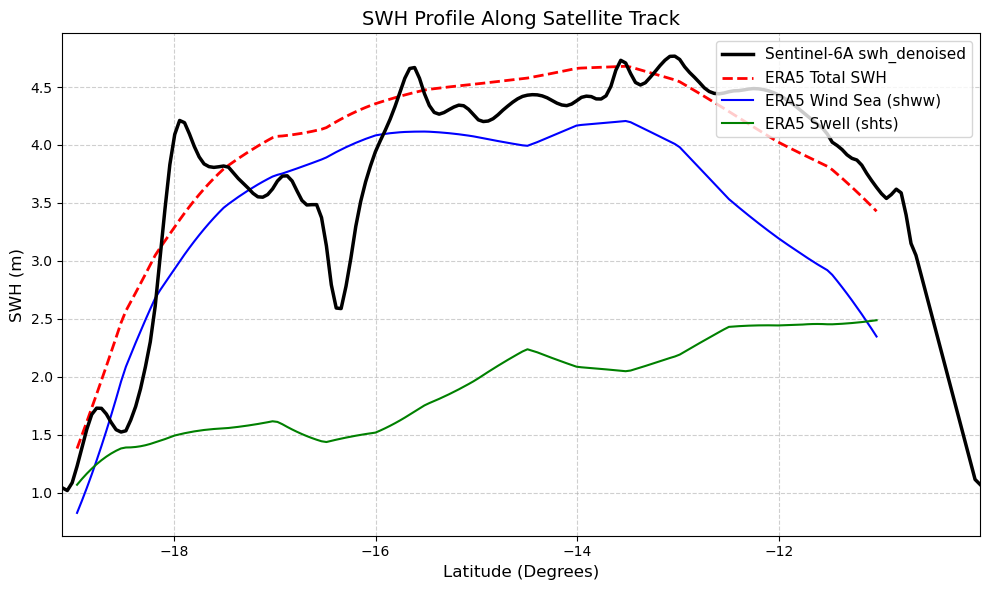

In [38]:
# Now we want to interpolate the ERA5 data on the Sentinel 6a track so to see in detail how the swh compare to each other and to also plot the two 
# components identified by the model: shww (significant height of wind waves) and the shts (significant height of total swell).

# We extract the 2D ERA5 data exactly along the 1D satellite track
era5_on_track = era5_step.interp(
    latitude=valid_s6.lat, 
    longitude=valid_s6.lon, 
    method='linear'
)

# Plot the 1D Profile
fig, ax = plt.subplots(figsize=(10, 6))

# Plot the satellite data
ax.plot(valid_s6.lat, valid_s6['swh_denoised'], label='Sentinel-6A swh_denoised', color='black', linewidth=2.5, zorder=5)

# Plot the ERA5 model data
if 'swh' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.swh, label='ERA5 Total SWH', color='red', linestyle='--', linewidth=2)
    
if 'shww' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.shww, label='ERA5 Wind Sea (shww)', color='blue', linewidth=1.5)
    
if 'shts' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.shts, label='ERA5 Swell (shts)', color='green', linewidth=1.5)

ax.set_xlabel('Latitude (Degrees)', fontsize=12)
ax.set_ylabel('SWH (m)', fontsize=12)
ax.set_title('SWH Profile Along Satellite Track', fontsize=14)

ax.set_xlim(float(valid_s6.lat.min()), float(valid_s6.lat.max()))

# Add grid and legend
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

Now, try applying this same analysis to the other examples provided. This will allow you to identify whether the high offshore SWH in each case is driven by local wind events or by the propagation of long-distance swells.

Furthermore, you can expand your investigation by exploring additional variables within the ERA5 dataset. Try to plot mdww (mean direction of wind waves) and mdts (mean direction of total swell) to observe the specific propagation directions of these individual wave components.

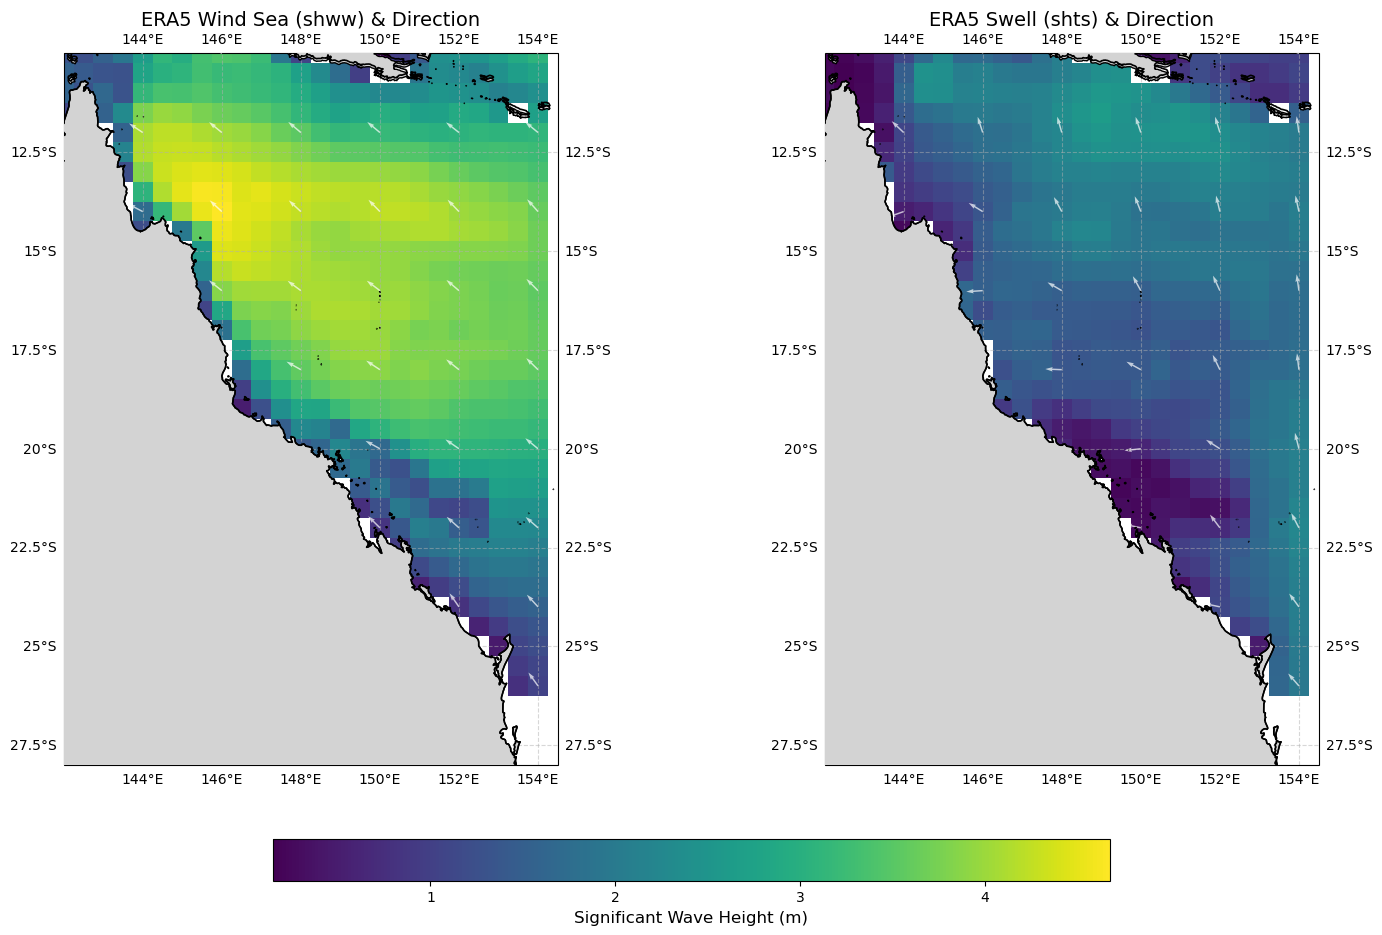

In [40]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax1, ax2 = axes

# Calculate shared color limits for accurate comparison between wind and swell
vmin = min(
    float(era5_step['shww'].min(skipna=True)),
    float(era5_step['shts'].min(skipna=True)),
)
vmax = max(
    float(era5_step['shww'].max(skipna=True)), 
    float(era5_step['shts'].max(skipna=True)), 
)

# Map features common to both subplots
def format_map(ax, title):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=6)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=14)

# PANEL 1: Wind Sea (shww) + Direction (mdww)

if 'shww' in era5_step:
    mesh1 = era5_step['shww'].plot.pcolormesh(
        ax=ax1, transform=ccrs.PlateCarree(), cmap='viridis', 
        vmin=vmin, vmax=vmax, add_colorbar=False, zorder=1
    )

if 'mdww' in era5_step:
    step = 4
    mdww_rad = np.radians(era5_step.mdww[::step, ::step].values)
    u_ww = -np.sin(mdww_rad)
    v_ww = -np.cos(mdww_rad)
    
    ax1.quiver(
        era5_step.longitude[::step].values, era5_step.latitude[::step].values,
        u_ww, v_ww, transform=ccrs.PlateCarree(),
        color='white', alpha=0.7, scale=30, width=0.003, zorder=3
    )

format_map(ax1, "ERA5 Wind Sea (shww) & Direction")

# PANEL 2: Swell (shts) + Direction (mdts)

if 'shts' in era5_step:
    mesh2 = era5_step['shts'].plot.pcolormesh(
        ax=ax2, transform=ccrs.PlateCarree(), cmap='viridis', 
        vmin=vmin, vmax=vmax, add_colorbar=False, zorder=1
    )

if 'mdts' in era5_step:
    step = 4
    mdts_rad = np.radians(era5_step.mdts[::step, ::step].values)
    u_ts = -np.sin(mdts_rad)
    v_ts = -np.cos(mdts_rad)
    
    ax2.quiver(
        era5_step.longitude[::step].values, era5_step.latitude[::step].values,
        u_ts, v_ts, transform=ccrs.PlateCarree(),
        color='white', alpha=0.7, scale=30, width=0.003, zorder=3
    )

format_map(ax2, "ERA5 Swell (shts) & Direction")

cbar = fig.colorbar(mesh1, ax=axes, orientation='horizontal', shrink=0.6, pad=0.08)
cbar.set_label('Significant Wave Height (m)', fontsize=12)

plt.show()

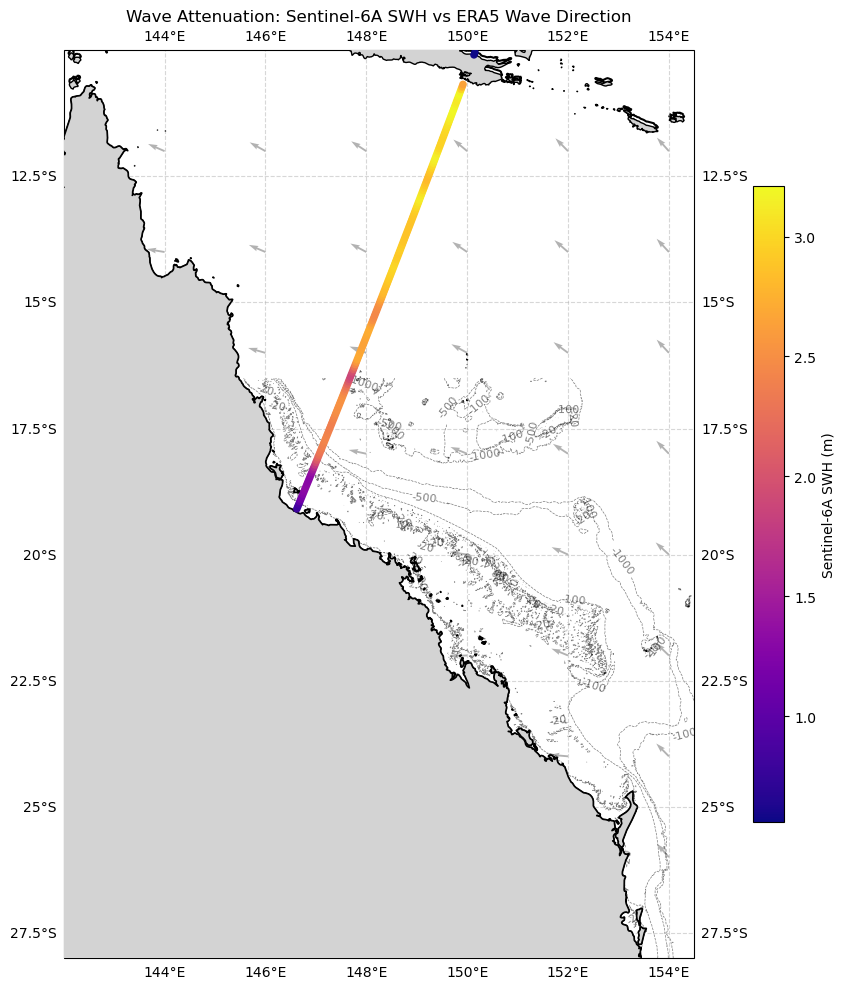

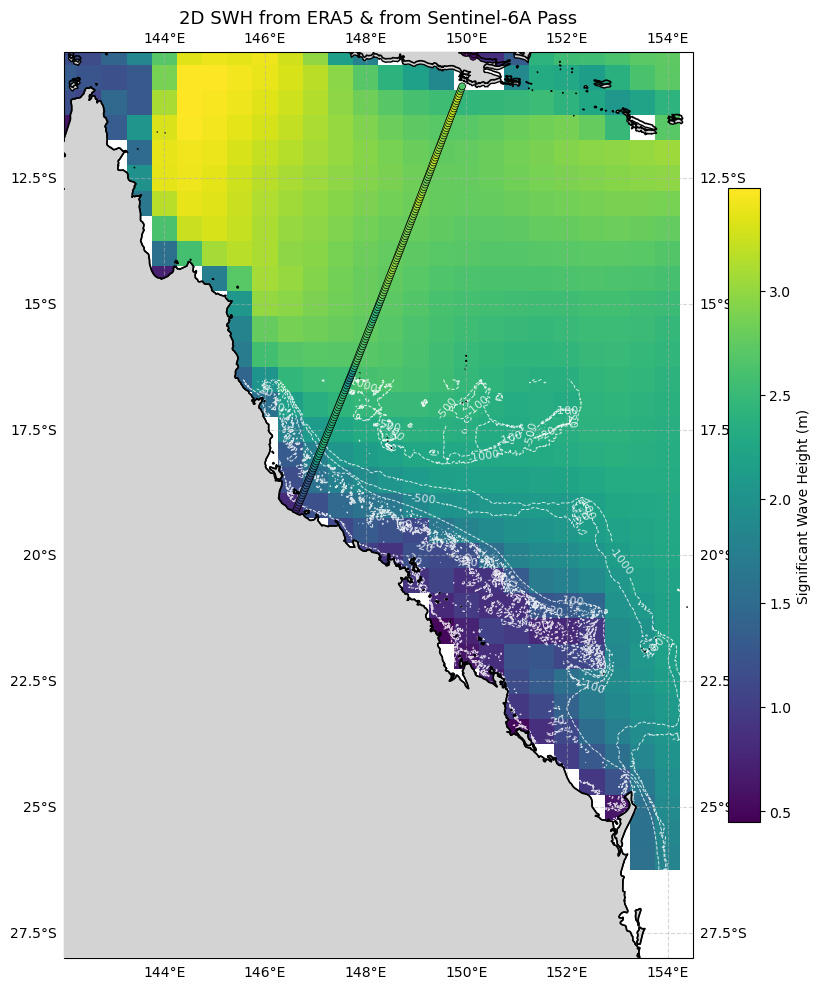

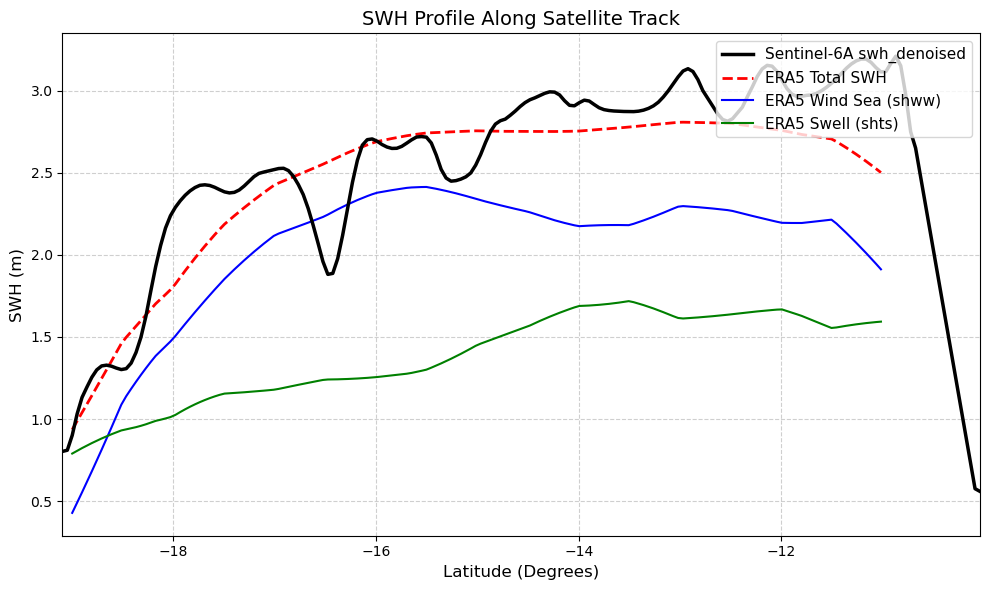

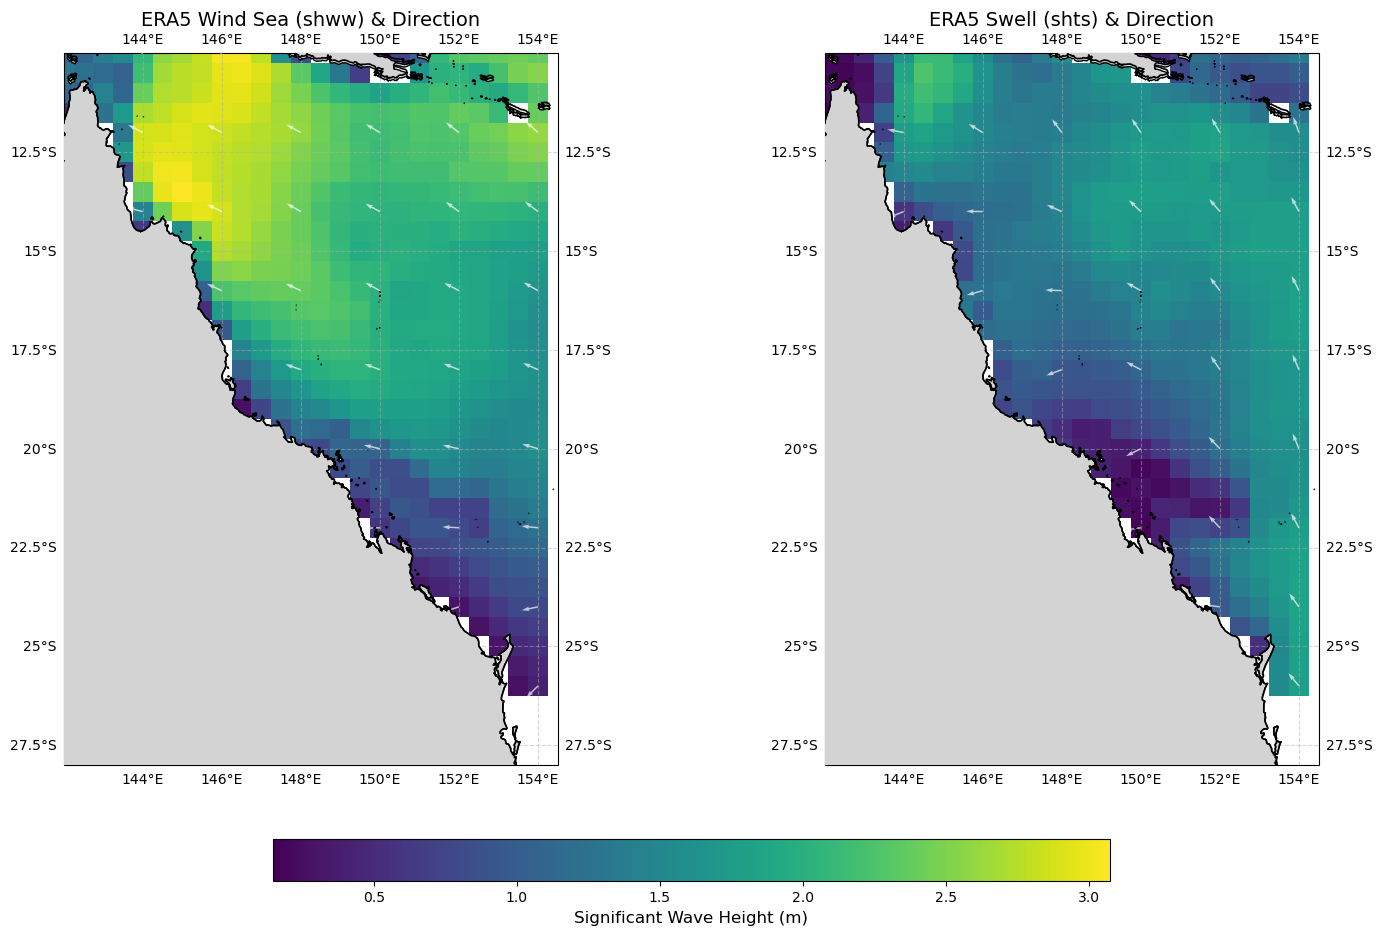

In [41]:
# EXAMPLE 2

ds_s6 = xr.open_dataset("data/eg2/ESACCI-SEASTATE-L2P-SWH-Sentinel-6_A-20210917T222827-fv01.nc")
ds_era5 = xr.open_dataset("data/eg2/20210917T22.nc")

# 1
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([142.0, 154.5, -28.0, -10.0], crs=ccrs.PlateCarree()) 

line_levels = [-1000, -500, -100, -20]
contours = ds_bathy.elevation.plot.contour(
    ax=ax, transform=ccrs.PlateCarree(), levels=line_levels, 
    colors='black', linewidths=0.5, alpha=0.5, add_colorbar=False
)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

era5_step = ds_era5.isel(valid_time=0) 

mwd_rad = np.radians(era5_step.mwd[::4, ::4])
u = -np.sin(mwd_rad)
v = -np.cos(mwd_rad)

ax.quiver(
    era5_step.longitude[::4], era5_step.latitude[::4], 
    u, v, 
    transform=ccrs.PlateCarree(), 
    color='gray', alpha=0.6, scale=35, width=0.003
)

lat_min, lat_max = -28.0, -10.0
lon_min, lon_max = 142.0, 154.5
valid_s6 = ds_s6.where(
    (ds_s6.swh_quality_level == 3) &
    (ds_s6.lat >= lat_min) & (ds_s6.lat <= lat_max) &
    (ds_s6.lon >= lon_min) & (ds_s6.lon <= lon_max),
    drop=True
)

sc = ax.scatter(
    valid_s6.lon, valid_s6.lat, 
    c=valid_s6.swh_denoised,
    s=20, cmap='plasma', transform=ccrs.PlateCarree(),
    zorder=5 
)
plt.colorbar(sc, ax=ax, label='Sentinel-6A SWH (m)', shrink=0.7, pad=0.05)

ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.title("Wave Attenuation: Sentinel-6A SWH vs ERA5 Wave Direction")
plt.tight_layout()
plt.show()

# 2
era5_min = float(era5_step['swh'].min(skipna=True)) if 'swh' in era5_step else np.inf
era5_max = float(era5_step['swh'].max(skipna=True)) if 'swh' in era5_step else -np.inf
s6_min = float(valid_s6['swh_denoised'].min(skipna=True))
s6_max = float(valid_s6['swh_denoised'].max(skipna=True))

global_min = min(era5_min, s6_min)
global_max = max(era5_max, s6_max)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([142.0, 154.5, -28.0, -10.0], crs=ccrs.PlateCarree())

if 'swh' in era5_step:
    swh_2d = era5_step['swh'].plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        vmin=global_min,
        vmax=global_max,
        zorder=1,
        add_colorbar=False
    )
else:
    print("Warning: No ERA5 'swh' variable found to plot.")

line_levels = [-1000, -500, -100, -20]
contours = ds_bathy.elevation.plot.contour(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=line_levels,
    colors='white',
    linewidths=0.7,
    alpha=0.8,
    add_colorbar=False,
    zorder=2
)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

sc = ax.scatter(
    valid_s6.lon,
    valid_s6.lat,
    c=valid_s6['swh_denoised'],
    s=25,
    cmap='viridis',    
    vmin=global_min,   
    vmax=global_max,   
    edgecolor='black',
    linewidth=0.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)
plt.colorbar(sc, ax=ax, label='Significant Wave Height (m)', shrink=0.7, pad=0.03)

ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.title("2D SWH from ERA5 & from Sentinel-6A Pass", fontsize=13)
plt.tight_layout()
plt.show()

# 3
era5_on_track = era5_step.interp(
    latitude=valid_s6.lat, 
    longitude=valid_s6.lon, 
    method='linear'
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(valid_s6.lat, valid_s6['swh_denoised'], label='Sentinel-6A swh_denoised', color='black', linewidth=2.5, zorder=5)

if 'swh' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.swh, label='ERA5 Total SWH', color='red', linestyle='--', linewidth=2)
    
if 'shww' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.shww, label='ERA5 Wind Sea (shww)', color='blue', linewidth=1.5)
    
if 'shts' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.shts, label='ERA5 Swell (shts)', color='green', linewidth=1.5)

ax.set_xlabel('Latitude (Degrees)', fontsize=12)
ax.set_ylabel('SWH (m)', fontsize=12)
ax.set_title('SWH Profile Along Satellite Track', fontsize=14)

ax.set_xlim(float(valid_s6.lat.min()), float(valid_s6.lat.max()))

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# 4
fig, axes = plt.subplots(1, 2, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax1, ax2 = axes

vmin = min(
    float(era5_step['shww'].min(skipna=True)),
    float(era5_step['shts'].min(skipna=True)),
)
vmax = max(
    float(era5_step['shww'].max(skipna=True)), 
    float(era5_step['shts'].max(skipna=True)), 
)

def format_map(ax, title):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=6)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=14)

if 'shww' in era5_step:
    mesh1 = era5_step['shww'].plot.pcolormesh(
        ax=ax1, transform=ccrs.PlateCarree(), cmap='viridis', 
        vmin=vmin, vmax=vmax, add_colorbar=False, zorder=1
    )

if 'mdww' in era5_step:
    step = 4
    mdww_rad = np.radians(era5_step.mdww[::step, ::step].values)
    u_ww = -np.sin(mdww_rad)
    v_ww = -np.cos(mdww_rad)
    
    ax1.quiver(
        era5_step.longitude[::step].values, era5_step.latitude[::step].values,
        u_ww, v_ww, transform=ccrs.PlateCarree(),
        color='white', alpha=0.7, scale=30, width=0.003, zorder=3
    )

format_map(ax1, "ERA5 Wind Sea (shww) & Direction")

if 'shts' in era5_step:
    mesh2 = era5_step['shts'].plot.pcolormesh(
        ax=ax2, transform=ccrs.PlateCarree(), cmap='viridis', 
        vmin=vmin, vmax=vmax, add_colorbar=False, zorder=1
    )

if 'mdts' in era5_step:
    step = 4
    mdts_rad = np.radians(era5_step.mdts[::step, ::step].values)
    u_ts = -np.sin(mdts_rad)
    v_ts = -np.cos(mdts_rad)
    
    ax2.quiver(
        era5_step.longitude[::step].values, era5_step.latitude[::step].values,
        u_ts, v_ts, transform=ccrs.PlateCarree(),
        color='white', alpha=0.7, scale=30, width=0.003, zorder=3
    )

format_map(ax2, "ERA5 Swell (shts) & Direction")

cbar = fig.colorbar(mesh1, ax=axes, orientation='horizontal', shrink=0.6, pad=0.08)
cbar.set_label('Significant Wave Height (m)', fontsize=12)

plt.show()

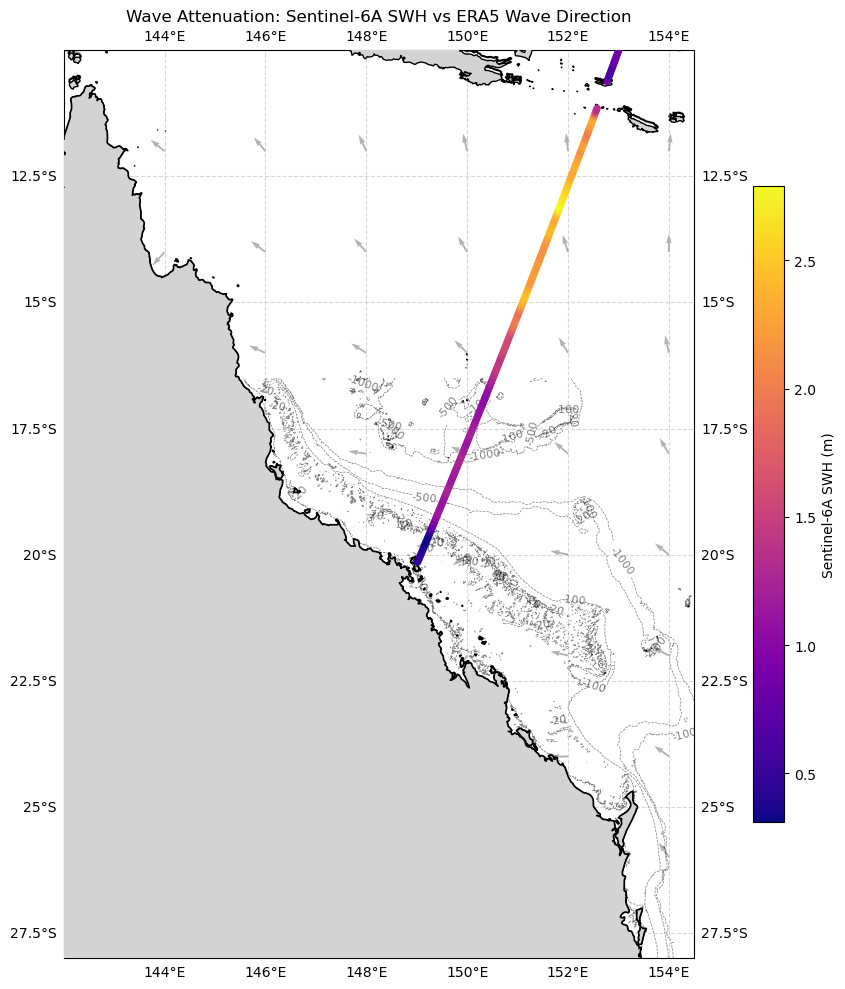

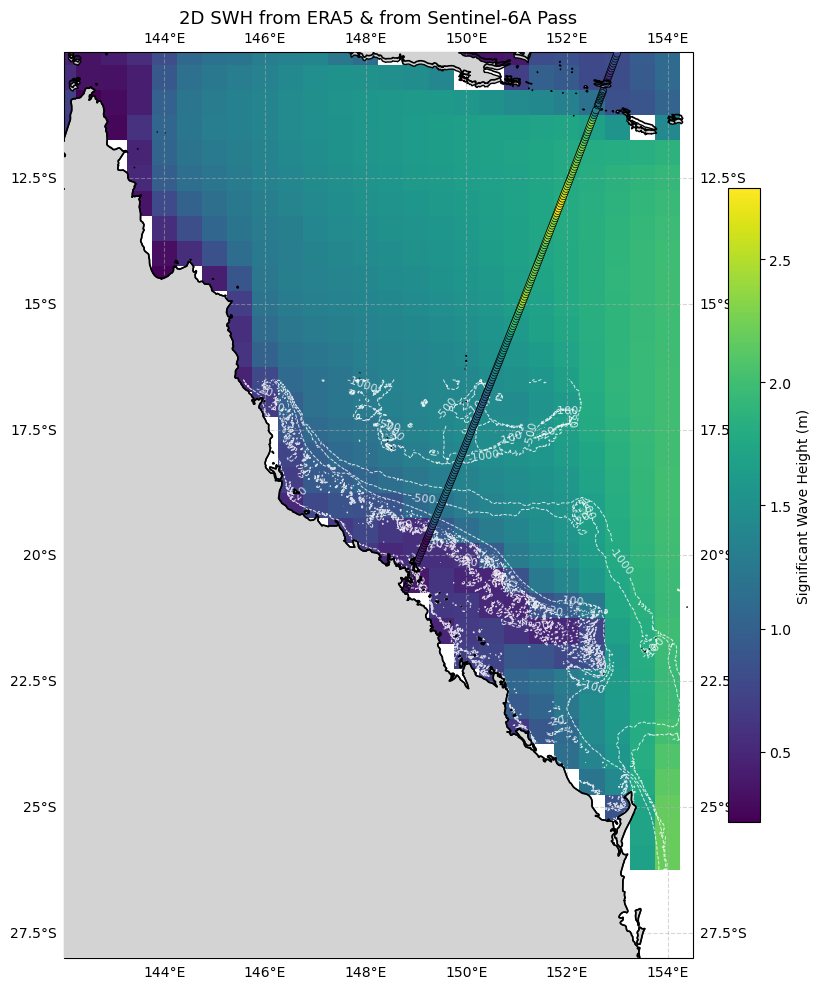

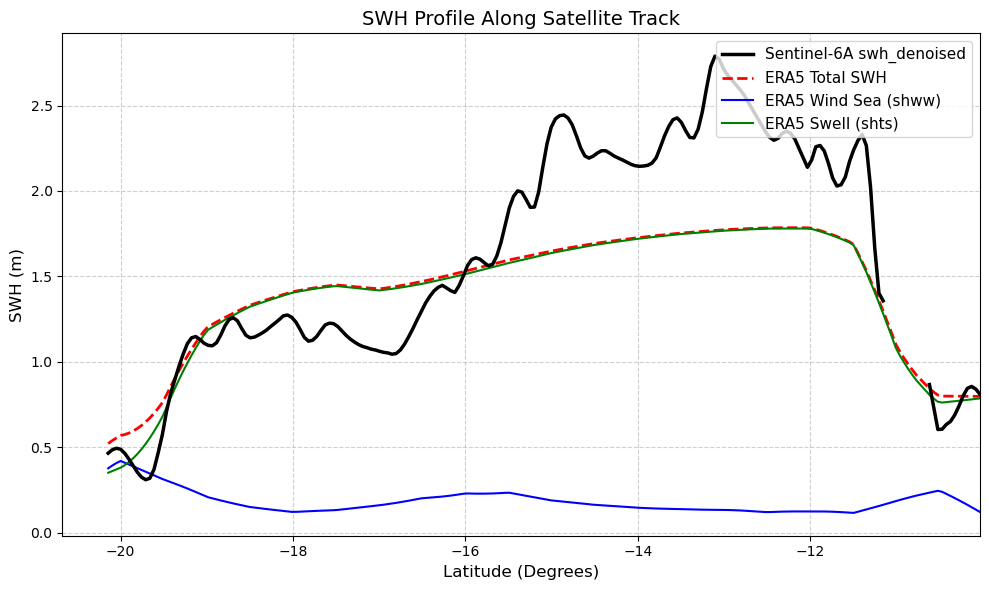

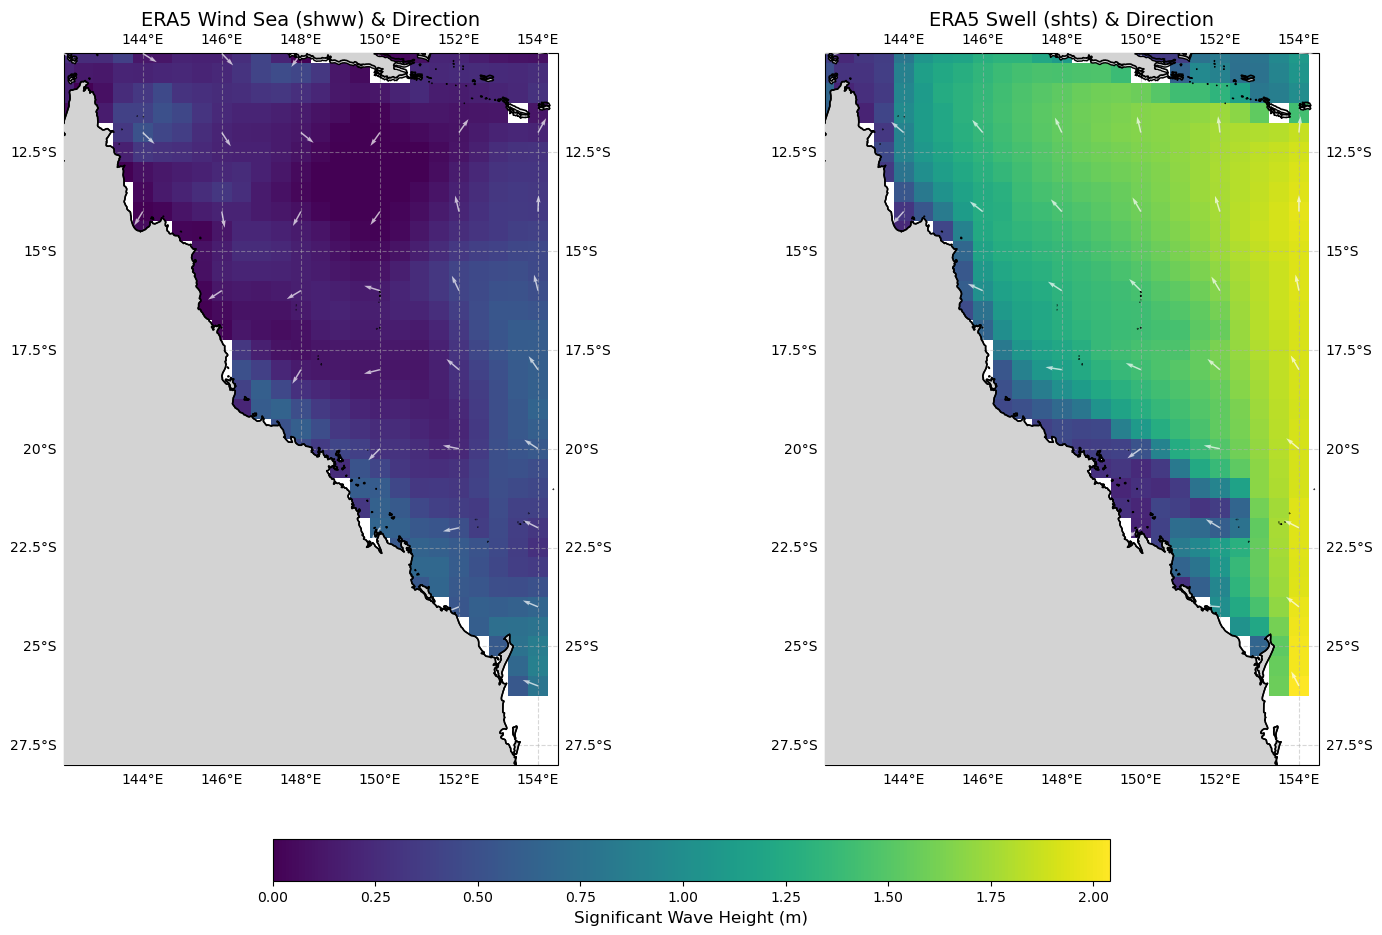

In [42]:
# EXAMPLE 3

ds_s6 = xr.open_dataset("data/eg3/ESACCI-SEASTATE-L2P-SWH-Sentinel-6_A-20210306T141015-fv01.nc")
ds_era5 = xr.open_dataset("data/eg3/20210306T14.nc")

# 1
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([142.0, 154.5, -28.0, -10.0], crs=ccrs.PlateCarree()) 

line_levels = [-1000, -500, -100, -20]
contours = ds_bathy.elevation.plot.contour(
    ax=ax, transform=ccrs.PlateCarree(), levels=line_levels, 
    colors='black', linewidths=0.5, alpha=0.5, add_colorbar=False
)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

era5_step = ds_era5.isel(valid_time=0) 

mwd_rad = np.radians(era5_step.mwd[::4, ::4])
u = -np.sin(mwd_rad)
v = -np.cos(mwd_rad)

ax.quiver(
    era5_step.longitude[::4], era5_step.latitude[::4], 
    u, v, 
    transform=ccrs.PlateCarree(), 
    color='gray', alpha=0.6, scale=35, width=0.003
)

lat_min, lat_max = -28.0, -10.0
lon_min, lon_max = 142.0, 154.5
valid_s6 = ds_s6.where(
    (ds_s6.swh_quality_level == 3) &
    (ds_s6.lat >= lat_min) & (ds_s6.lat <= lat_max) &
    (ds_s6.lon >= lon_min) & (ds_s6.lon <= lon_max),
    drop=True
)

sc = ax.scatter(
    valid_s6.lon, valid_s6.lat, 
    c=valid_s6.swh_denoised,
    s=20, cmap='plasma', transform=ccrs.PlateCarree(),
    zorder=5 
)
plt.colorbar(sc, ax=ax, label='Sentinel-6A SWH (m)', shrink=0.7, pad=0.05)

ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.title("Wave Attenuation: Sentinel-6A SWH vs ERA5 Wave Direction")
plt.tight_layout()
plt.show()

# 2
era5_min = float(era5_step['swh'].min(skipna=True)) if 'swh' in era5_step else np.inf
era5_max = float(era5_step['swh'].max(skipna=True)) if 'swh' in era5_step else -np.inf
s6_min = float(valid_s6['swh_denoised'].min(skipna=True))
s6_max = float(valid_s6['swh_denoised'].max(skipna=True))

global_min = min(era5_min, s6_min)
global_max = max(era5_max, s6_max)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([142.0, 154.5, -28.0, -10.0], crs=ccrs.PlateCarree())

if 'swh' in era5_step:
    swh_2d = era5_step['swh'].plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        vmin=global_min,
        vmax=global_max,
        zorder=1,
        add_colorbar=False
    )
else:
    print("Warning: No ERA5 'swh' variable found to plot.")

line_levels = [-1000, -500, -100, -20]
contours = ds_bathy.elevation.plot.contour(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=line_levels,
    colors='white',
    linewidths=0.7,
    alpha=0.8,
    add_colorbar=False,
    zorder=2
)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

sc = ax.scatter(
    valid_s6.lon,
    valid_s6.lat,
    c=valid_s6['swh_denoised'],
    s=25,
    cmap='viridis',    
    vmin=global_min,   
    vmax=global_max,   
    edgecolor='black',
    linewidth=0.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)
plt.colorbar(sc, ax=ax, label='Significant Wave Height (m)', shrink=0.7, pad=0.03)

ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.title("2D SWH from ERA5 & from Sentinel-6A Pass", fontsize=13)
plt.tight_layout()
plt.show()

# 3
era5_on_track = era5_step.interp(
    latitude=valid_s6.lat, 
    longitude=valid_s6.lon, 
    method='linear'
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(valid_s6.lat, valid_s6['swh_denoised'], label='Sentinel-6A swh_denoised', color='black', linewidth=2.5, zorder=5)

if 'swh' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.swh, label='ERA5 Total SWH', color='red', linestyle='--', linewidth=2)
    
if 'shww' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.shww, label='ERA5 Wind Sea (shww)', color='blue', linewidth=1.5)
    
if 'shts' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.shts, label='ERA5 Swell (shts)', color='green', linewidth=1.5)

ax.set_xlabel('Latitude (Degrees)', fontsize=12)
ax.set_ylabel('SWH (m)', fontsize=12)
ax.set_title('SWH Profile Along Satellite Track', fontsize=14)

ax.set_xlim(float(valid_s6.lat.min()), float(valid_s6.lat.max()))

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# 4
fig, axes = plt.subplots(1, 2, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax1, ax2 = axes

vmin = min(
    float(era5_step['shww'].min(skipna=True)),
    float(era5_step['shts'].min(skipna=True)),
)
vmax = max(
    float(era5_step['shww'].max(skipna=True)), 
    float(era5_step['shts'].max(skipna=True)), 
)

def format_map(ax, title):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=6)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=14)

if 'shww' in era5_step:
    mesh1 = era5_step['shww'].plot.pcolormesh(
        ax=ax1, transform=ccrs.PlateCarree(), cmap='viridis', 
        vmin=vmin, vmax=vmax, add_colorbar=False, zorder=1
    )

if 'mdww' in era5_step:
    step = 4
    mdww_rad = np.radians(era5_step.mdww[::step, ::step].values)
    u_ww = -np.sin(mdww_rad)
    v_ww = -np.cos(mdww_rad)
    
    ax1.quiver(
        era5_step.longitude[::step].values, era5_step.latitude[::step].values,
        u_ww, v_ww, transform=ccrs.PlateCarree(),
        color='white', alpha=0.7, scale=30, width=0.003, zorder=3
    )

format_map(ax1, "ERA5 Wind Sea (shww) & Direction")

if 'shts' in era5_step:
    mesh2 = era5_step['shts'].plot.pcolormesh(
        ax=ax2, transform=ccrs.PlateCarree(), cmap='viridis', 
        vmin=vmin, vmax=vmax, add_colorbar=False, zorder=1
    )

if 'mdts' in era5_step:
    step = 4
    mdts_rad = np.radians(era5_step.mdts[::step, ::step].values)
    u_ts = -np.sin(mdts_rad)
    v_ts = -np.cos(mdts_rad)
    
    ax2.quiver(
        era5_step.longitude[::step].values, era5_step.latitude[::step].values,
        u_ts, v_ts, transform=ccrs.PlateCarree(),
        color='white', alpha=0.7, scale=30, width=0.003, zorder=3
    )

format_map(ax2, "ERA5 Swell (shts) & Direction")

cbar = fig.colorbar(mesh1, ax=axes, orientation='horizontal', shrink=0.6, pad=0.08)
cbar.set_label('Significant Wave Height (m)', fontsize=12)

plt.show()

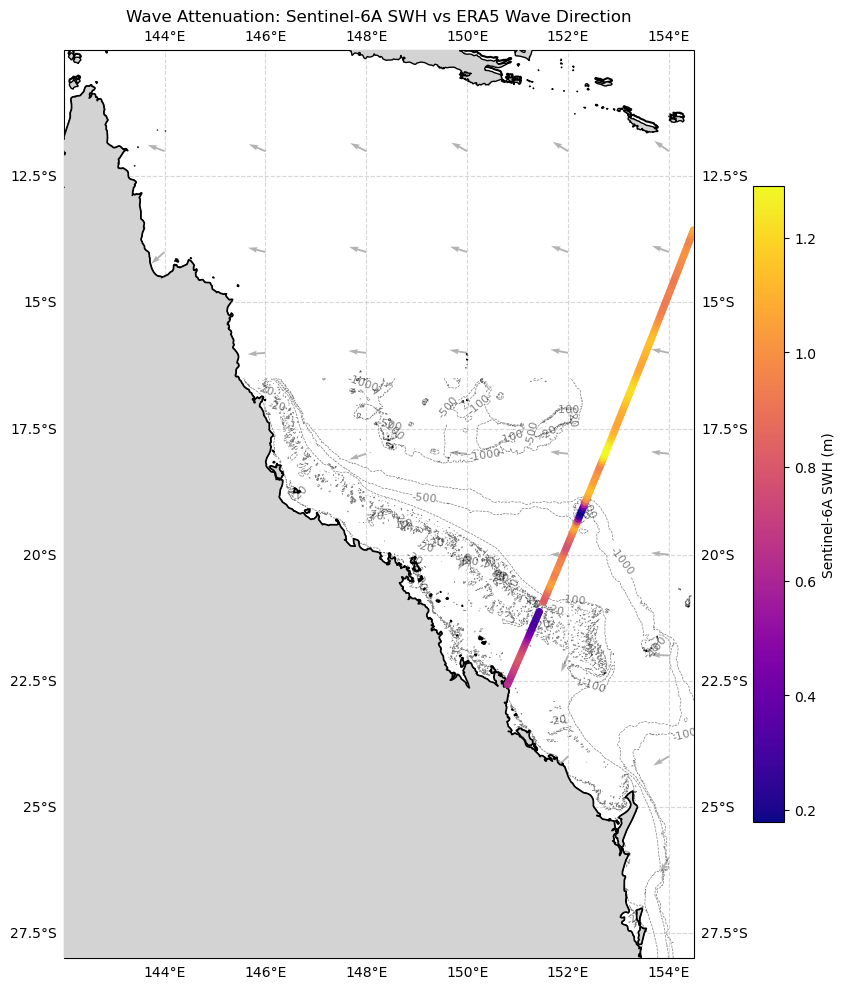

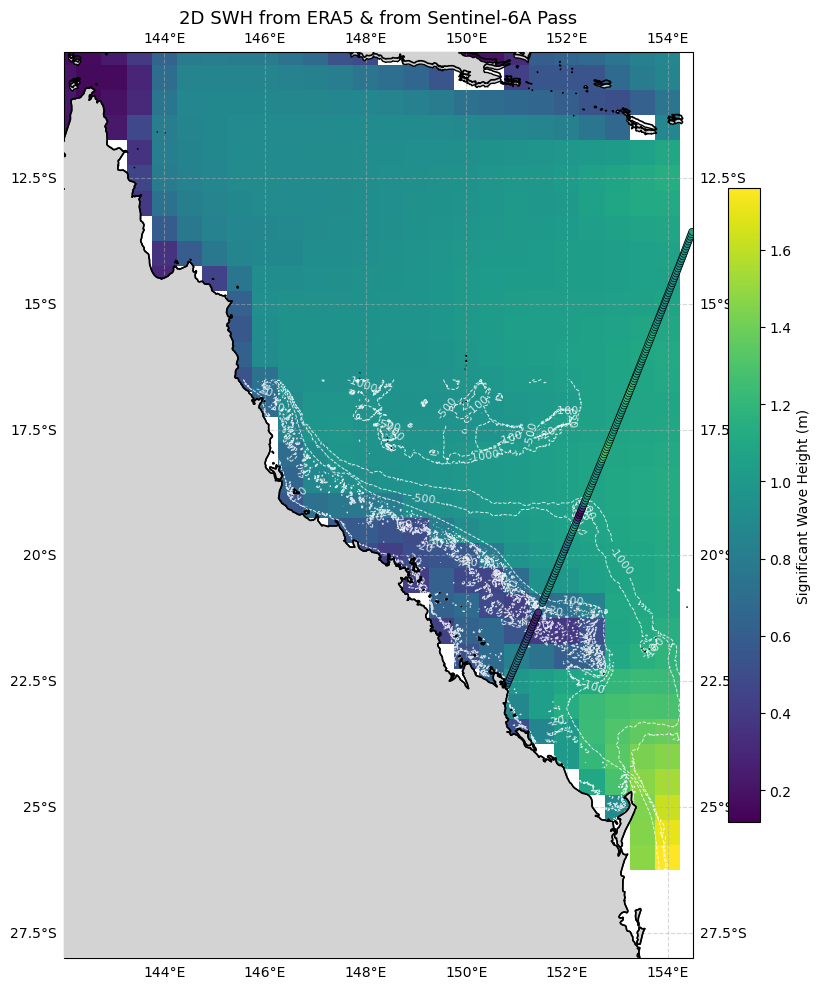

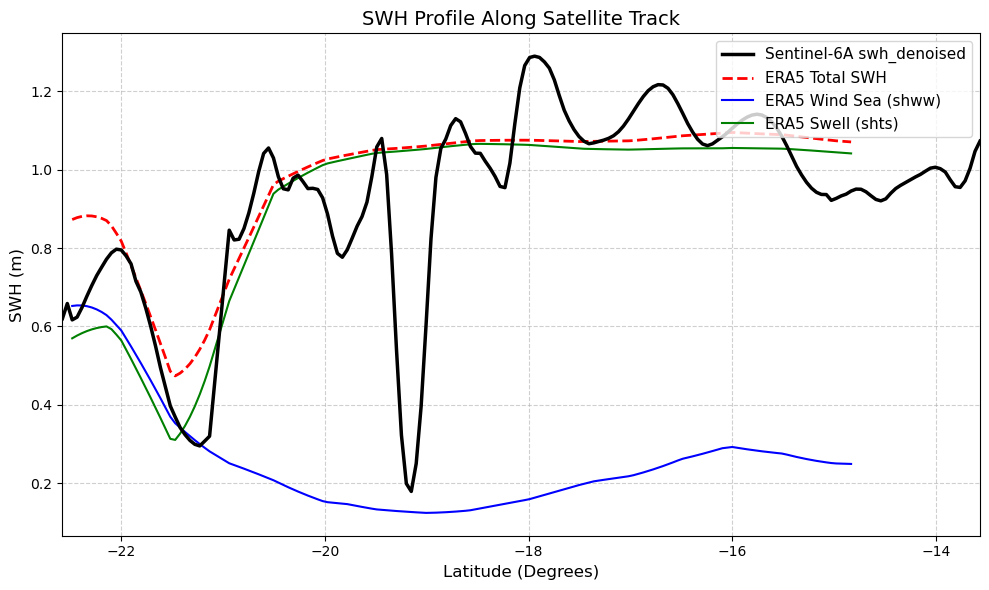

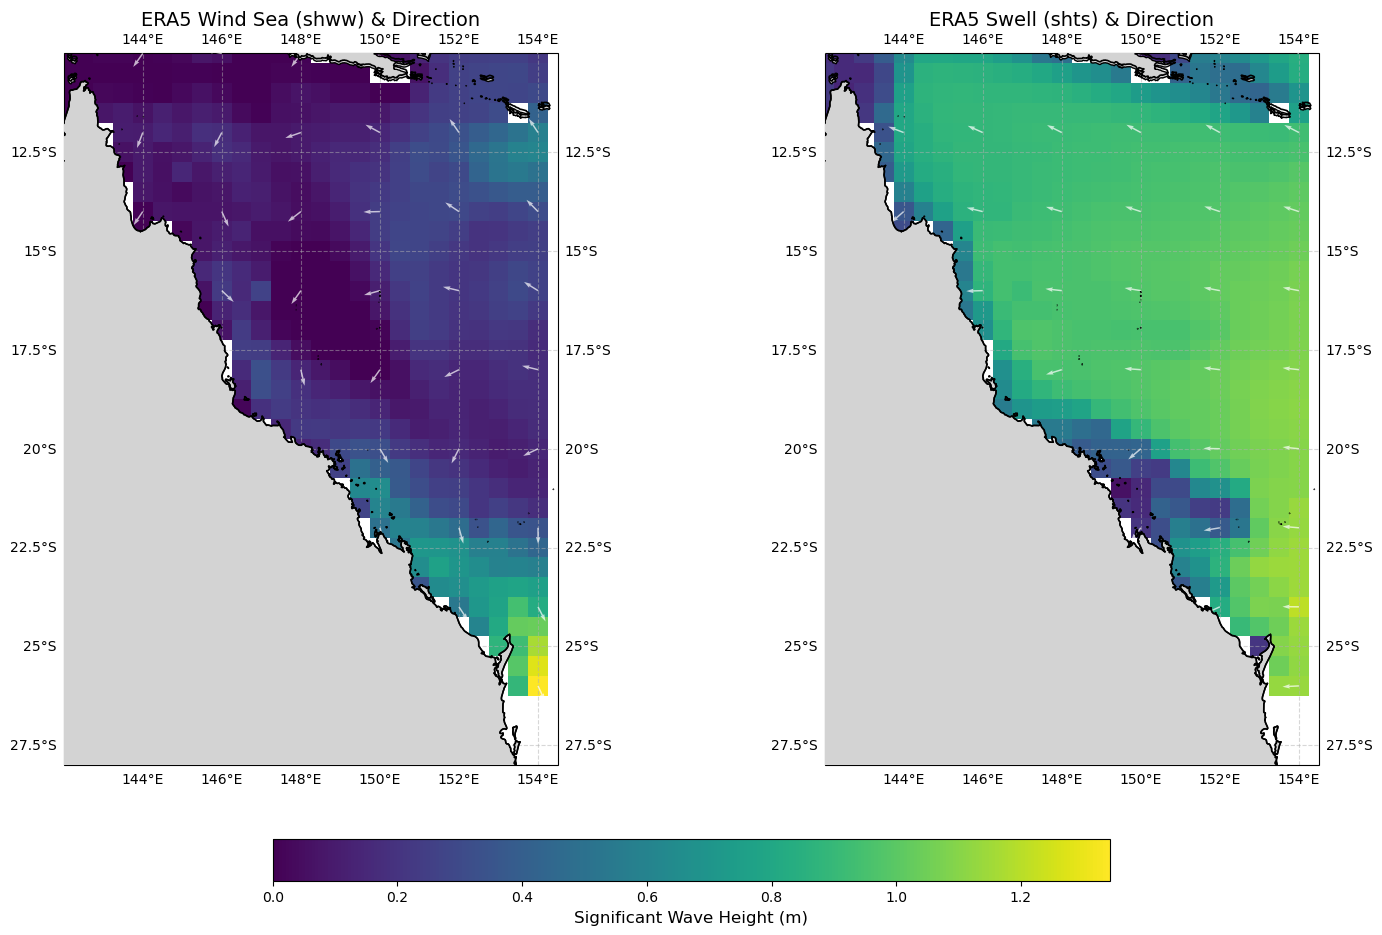

In [43]:
# EXAMPLE 4

ds_s6 = xr.open_dataset("data/eg4/ESACCI-SEASTATE-L2P-SWH-Sentinel-6_A-20211003T185136-fv01.nc")
ds_era5 = xr.open_dataset("data/eg4/20211003T19.nc")

# 1
fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([142.0, 154.5, -28.0, -10.0], crs=ccrs.PlateCarree()) 

line_levels = [-1000, -500, -100, -20]
contours = ds_bathy.elevation.plot.contour(
    ax=ax, transform=ccrs.PlateCarree(), levels=line_levels, 
    colors='black', linewidths=0.5, alpha=0.5, add_colorbar=False
)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

era5_step = ds_era5.isel(valid_time=0) 

mwd_rad = np.radians(era5_step.mwd[::4, ::4])
u = -np.sin(mwd_rad)
v = -np.cos(mwd_rad)

ax.quiver(
    era5_step.longitude[::4], era5_step.latitude[::4], 
    u, v, 
    transform=ccrs.PlateCarree(), 
    color='gray', alpha=0.6, scale=35, width=0.003
)

lat_min, lat_max = -28.0, -10.0
lon_min, lon_max = 142.0, 154.5
valid_s6 = ds_s6.where(
    (ds_s6.swh_quality_level == 3) &
    (ds_s6.lat >= lat_min) & (ds_s6.lat <= lat_max) &
    (ds_s6.lon >= lon_min) & (ds_s6.lon <= lon_max),
    drop=True
)

sc = ax.scatter(
    valid_s6.lon, valid_s6.lat, 
    c=valid_s6.swh_denoised,
    s=20, cmap='plasma', transform=ccrs.PlateCarree(),
    zorder=5 
)
plt.colorbar(sc, ax=ax, label='Sentinel-6A SWH (m)', shrink=0.7, pad=0.05)

ax.add_feature(cfeature.COASTLINE, linewidth=1.5)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.title("Wave Attenuation: Sentinel-6A SWH vs ERA5 Wave Direction")
plt.tight_layout()
plt.show()

# 2
era5_min = float(era5_step['swh'].min(skipna=True)) if 'swh' in era5_step else np.inf
era5_max = float(era5_step['swh'].max(skipna=True)) if 'swh' in era5_step else -np.inf
s6_min = float(valid_s6['swh_denoised'].min(skipna=True))
s6_max = float(valid_s6['swh_denoised'].max(skipna=True))

global_min = min(era5_min, s6_min)
global_max = max(era5_max, s6_max)

fig, ax = plt.subplots(figsize=(12, 10), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([142.0, 154.5, -28.0, -10.0], crs=ccrs.PlateCarree())

if 'swh' in era5_step:
    swh_2d = era5_step['swh'].plot.pcolormesh(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='viridis',
        vmin=global_min,
        vmax=global_max,
        zorder=1,
        add_colorbar=False
    )
else:
    print("Warning: No ERA5 'swh' variable found to plot.")

line_levels = [-1000, -500, -100, -20]
contours = ds_bathy.elevation.plot.contour(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=line_levels,
    colors='white',
    linewidths=0.7,
    alpha=0.8,
    add_colorbar=False,
    zorder=2
)
ax.clabel(contours, inline=True, fontsize=8, fmt='%1.0f')

sc = ax.scatter(
    valid_s6.lon,
    valid_s6.lat,
    c=valid_s6['swh_denoised'],
    s=25,
    cmap='viridis',    
    vmin=global_min,   
    vmax=global_max,   
    edgecolor='black',
    linewidth=0.5,
    transform=ccrs.PlateCarree(),
    zorder=5
)
plt.colorbar(sc, ax=ax, label='Significant Wave Height (m)', shrink=0.7, pad=0.03)

ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=6)
ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)

plt.title("2D SWH from ERA5 & from Sentinel-6A Pass", fontsize=13)
plt.tight_layout()
plt.show()

# 3
era5_on_track = era5_step.interp(
    latitude=valid_s6.lat, 
    longitude=valid_s6.lon, 
    method='linear'
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(valid_s6.lat, valid_s6['swh_denoised'], label='Sentinel-6A swh_denoised', color='black', linewidth=2.5, zorder=5)

if 'swh' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.swh, label='ERA5 Total SWH', color='red', linestyle='--', linewidth=2)
    
if 'shww' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.shww, label='ERA5 Wind Sea (shww)', color='blue', linewidth=1.5)
    
if 'shts' in era5_on_track:
    ax.plot(valid_s6.lat, era5_on_track.shts, label='ERA5 Swell (shts)', color='green', linewidth=1.5)

ax.set_xlabel('Latitude (Degrees)', fontsize=12)
ax.set_ylabel('SWH (m)', fontsize=12)
ax.set_title('SWH Profile Along Satellite Track', fontsize=14)

ax.set_xlim(float(valid_s6.lat.min()), float(valid_s6.lat.max()))

ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# 4
fig, axes = plt.subplots(1, 2, figsize=(18, 12), subplot_kw={'projection': ccrs.PlateCarree()})
ax1, ax2 = axes

vmin = min(
    float(era5_step['shww'].min(skipna=True)),
    float(era5_step['shts'].min(skipna=True)),
)
vmax = max(
    float(era5_step['shww'].max(skipna=True)), 
    float(era5_step['shts'].max(skipna=True)), 
)

def format_map(ax, title):
    ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, zorder=6)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', edgecolor='black', zorder=4)
    ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
    ax.set_title(title, fontsize=14)

if 'shww' in era5_step:
    mesh1 = era5_step['shww'].plot.pcolormesh(
        ax=ax1, transform=ccrs.PlateCarree(), cmap='viridis', 
        vmin=vmin, vmax=vmax, add_colorbar=False, zorder=1
    )

if 'mdww' in era5_step:
    step = 4
    mdww_rad = np.radians(era5_step.mdww[::step, ::step].values)
    u_ww = -np.sin(mdww_rad)
    v_ww = -np.cos(mdww_rad)
    
    ax1.quiver(
        era5_step.longitude[::step].values, era5_step.latitude[::step].values,
        u_ww, v_ww, transform=ccrs.PlateCarree(),
        color='white', alpha=0.7, scale=30, width=0.003, zorder=3
    )

format_map(ax1, "ERA5 Wind Sea (shww) & Direction")

if 'shts' in era5_step:
    mesh2 = era5_step['shts'].plot.pcolormesh(
        ax=ax2, transform=ccrs.PlateCarree(), cmap='viridis', 
        vmin=vmin, vmax=vmax, add_colorbar=False, zorder=1
    )

if 'mdts' in era5_step:
    step = 4
    mdts_rad = np.radians(era5_step.mdts[::step, ::step].values)
    u_ts = -np.sin(mdts_rad)
    v_ts = -np.cos(mdts_rad)
    
    ax2.quiver(
        era5_step.longitude[::step].values, era5_step.latitude[::step].values,
        u_ts, v_ts, transform=ccrs.PlateCarree(),
        color='white', alpha=0.7, scale=30, width=0.003, zorder=3
    )

format_map(ax2, "ERA5 Swell (shts) & Direction")

cbar = fig.colorbar(mesh1, ax=axes, orientation='horizontal', shrink=0.6, pad=0.08)
cbar.set_label('Significant Wave Height (m)', fontsize=12)

plt.show()